## IMPUTATION OF MISSING GROUNDWATER LEVEL VALUES

Compact reproducible workflow.

In [1]:
import io
import os
import zipfile
from collections import OrderedDict

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import shap

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Load and filter data

In [2]:
file_id = '11TvlNdqSQv6PPooHwt7f9A68Ibz1sQIU'
zip_url = f'https://drive.google.com/uc?export=download&id={file_id}'

response = requests.get(zip_url)
if response.status_code != 200:
    raise RuntimeError('Failed to download the groundwater dataset.')

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

wells_of_interest = ['LT_35994', 'LT_35995', 'LT_35996', 'LV_12225', 'LV_22606', 'LV_22610', 'LT_220']
df['date'] = pd.to_datetime(df['date'])
df = df[df['well_no'].isin(wells_of_interest) & (df['date'] >= pd.Timestamp('2003-01-01'))].copy()
df.head()

/tmp/ipykernel_606/3702864760.py:10: DtypeWarning: Columns (6,38,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


,date,well_no,precipitation_mm_eobs,temperature_C_eobs,actual_evapotranspiration_mm_gleam,potential_evapotranspiration_mm_gleam,site,local_ID,altitude_ m_asl,gw_level_m_asl,...,top_of_screen,bottom_of_screen,geometry,date_left,index_right,lat,lon,date_right,tws_mm_tavg_gldas,gws_mm_tavg_gldas
232300,2003-01-01,LT_220,0.8,-6.75,0.032450,0.032450,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.69305907439 56.20920104507),NaN,NaN,NaN,NaN,NaN,NaN,NaN
232302,2003-01-01,LT_35994,0.9,-6.77,0.037250,0.037250,NaN,NaN,NaN,NaN,...,9.2,11.2,POINT (24.774293399674 56.193088509493),NaN,NaN,NaN,NaN,NaN,NaN,NaN
232303,2003-01-01,LT_35995,0.8,-6.75,0.032450,0.032450,NaN,NaN,NaN,NaN,...,18.5,20.5,POINT (24.693363994862 56.209127471519),NaN,NaN,NaN,NaN,NaN,NaN,NaN
232304,2003-01-01,LT_35996,0.0,-6.09,0.047098,0.047098,NaN,NaN,NaN,NaN,...,33.0,35.0,POINT (24.238025045474 56.159100150554),NaN,NaN,NaN,NaN,NaN,NaN,NaN
232305,2003-01-01,LV_22610,1.4,-6.61,0.037088,0.037088,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.7002 56.40388),NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Feature engineering

In [3]:
df['date'] = pd.to_datetime(df['date'])
df_orig = df.copy()
df_work = df_orig.copy().sort_values(['well_no', 'date'])

base_features = [
    'precipitation_mm_eobs',
    'temperature_C_eobs',
    'actual_evapotranspiration_mm_gleam',
    'gws_mm_tavg_gldas',
    'gw_level_m_asl',
]
target_col = 'gw_level_m_asl'
lag_days = [30, 60, 90, 180, 270, 360]
roll_days = [60, 90]

all_feature_names = []
for col in base_features:
    for lag in lag_days:
        all_feature_names.append(f'{col}_lag_{lag}d')
    for win in roll_days:
        suffix = 'rollsum' if col in ['precipitation_mm_eobs', 'actual_evapotranspiration_mm_gleam'] else 'rollmean'
        all_feature_names.append(f'{col}_{suffix}_{win}d')

for col in base_features:
    grouped = df_work.groupby('well_no')[col]
    for lag in lag_days:
        df_work[f'{col}_lag_{lag}d'] = grouped.shift(lag)
    for win in roll_days:
        if col == 'precipitation_mm_eobs':
            df_work[f'{col}_rollsum_{win}d'] = grouped.transform(lambda x: x.rolling(win, min_periods=1).sum())
        else:
            df_work[f'{col}_rollmean_{win}d'] = grouped.transform(lambda x: x.rolling(win, min_periods=1).mean())

df_work['dayofyear'] = df_work['date'].dt.dayofyear
df_work['sin_doy'] = np.sin(2 * np.pi * df_work['dayofyear'] / 365.25)
df_work['cos_doy'] = np.cos(2 * np.pi * df_work['dayofyear'] / 365.25)
df_work['month'] = df_work['date'].dt.month
df_work['sin_month'] = np.sin(2 * np.pi * df_work['month'] / 12)
df_work['cos_month'] = np.cos(2 * np.pi * df_work['month'] / 12)
df_work['sin_annual'] = np.sin(2 * np.pi * df_work['date'].dt.dayofyear / 365.25)
df_work['cos_annual'] = np.cos(2 * np.pi * df_work['date'].dt.dayofyear / 365.25)
df_work['seasonal_phase'] = np.arctan2(df_work['sin_doy'], df_work['cos_doy'])

df_work['precip_anomaly'] = (
    df_work['precipitation_mm_eobs_rollsum_90d']
    - df_work.groupby('well_no')['precipitation_mm_eobs'].transform(lambda x: x.rolling(365, min_periods=180).mean())
)
df_work['drought_flag'] = df_work['precip_anomaly'] < -1.5

df_work['gws_monthly_mean'] = df_work.groupby(df_work['date'].dt.month)['gws_mm_tavg_gldas'].transform('mean')
df_work['gws_monthly_anomaly'] = df_work['gws_mm_tavg_gldas'] - df_work['gws_monthly_mean']
df_work['gws_delta_30d'] = df_work['gws_mm_tavg_gldas'] - df_work['gws_mm_tavg_gldas_lag_30d']
df_work['gws_recharge_event'] = df_work['gws_delta_30d'] > df_work['gws_delta_30d'].quantile(0.9)

df_work['below_zero_rolling_30d'] = df_work['temperature_C_eobs'].rolling(30, min_periods=30).apply(
    lambda x: np.mean(x < 0), raw=True
)
df_work['permafrost_flag'] = df_work['below_zero_rolling_30d'] > 0.8

monthly_avg = df_work.groupby(df_work['date'].dt.month).agg({
    'temperature_C_eobs': 'mean',
    'precipitation_mm_eobs': 'mean',
    'gws_mm_tavg_gldas': 'mean',
}).rename(columns={
    'temperature_C_eobs': 'temp_monthly_avg',
    'precipitation_mm_eobs': 'precip_monthly_avg',
    'gws_mm_tavg_gldas': 'gws_monthly_avg',
})

df_work['temp_monthly_avg'] = df_work['month'].map(monthly_avg['temp_monthly_avg'])
df_work['precip_monthly_avg'] = df_work['month'].map(monthly_avg['precip_monthly_avg'])
df_work['gws_monthly_avg'] = df_work['month'].map(monthly_avg['gws_monthly_avg'])

### Signal cleaning / processing

In [4]:
df_work['gw_level_m_asl_original'] = df_work['gw_level_m_asl']
df_work = df_work.sort_values(['well_no', 'date'])

diff_forward = df_work.groupby('well_no')['gw_level_m_asl'].diff().abs()
diff_backward = df_work.groupby('well_no')['gw_level_m_asl'].diff(-1).abs()
threshold = df_work['gw_level_m_asl'].diff().abs().quantile(0.9995)
steep_mask = (diff_forward > threshold) | (diff_backward > threshold)

df_work.loc[steep_mask, 'gw_level_m_asl'] = np.nan
df_work.loc[
    (df_work['well_no'] == 'LT_35996') & (df_work['date'] >= pd.Timestamp('2022-06-01')),
    'gw_level_m_asl',
] = np.nan

dec_31_df = df_work[(df_work['date'].dt.month == 12) & (df_work['date'].dt.day == 31)]
avg_gw_levels = dec_31_df.groupby('well_no')['gw_level_m_asl'].mean()
mask = (df_work['date'] == pd.Timestamp('2023-12-31')) & df_work['gw_level_m_asl'].isna()

for idx in df_work[mask].index:
    well = df_work.loc[idx, 'well_no']
    if well in avg_gw_levels:
        df_work.at[idx, 'gw_level_m_asl'] = avg_gw_levels[well]

### Feature sets

In [5]:
feature_sets = {
    'with_seasonal': [
        'precipitation_mm_eobs_rollsum_90d',
        'temperature_C_eobs_lag_30d',
        'temperature_C_eobs_lag_90d',
        'temperature_C_eobs_lag_180d',
        'temperature_C_eobs_lag_270d',
        'temperature_C_eobs_lag_360d',
        'gws_mm_tavg_gldas_lag_90d',
        'gws_mm_tavg_gldas_lag_180d',
        'gws_mm_tavg_gldas_lag_270d',
        'gws_mm_tavg_gldas_lag_360d',
        'gws_mm_tavg_gldas',
        'seasonal_phase',
        'precip_monthly_avg',
    ],
    'no_seasonal': [
        'precipitation_mm_eobs_rollsum_90d',
        'temperature_C_eobs_lag_30d',
        'temperature_C_eobs_lag_90d',
        'temperature_C_eobs_lag_180d',
        'temperature_C_eobs_lag_270d',
        'temperature_C_eobs_lag_360d',
        'gws_mm_tavg_gldas_lag_90d',
        'gws_mm_tavg_gldas_lag_180d',
        'gws_mm_tavg_gldas_lag_270d',
        'gws_mm_tavg_gldas_lag_360d',
        'gws_mm_tavg_gldas',
    ],
}

### Model configuration

In [6]:
target_col = 'gw_level_m_asl'
min_samples_required = 5
min_features_ratio = 0.5
eval_fraction = 0.2
cv_fraction = 0.2
cv_repeats = 5
min_mask_length = 7
max_mask_length = 60

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2],
}

models = {
    'ExtraTreesTuned': GridSearchCV(
        ExtraTreesRegressor(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1,
    )
}

def generate_random_intervals(data, total_target_count, min_len=7, max_len=30, max_attempts=1000):
    data = data.reset_index()
    selected_idx = set()
    attempts = 0
    while len(selected_idx) < total_target_count and attempts < max_attempts:
        interval_len = np.random.randint(min_len, max_len + 1)
        if len(data) <= interval_len:
            break
        start_idx = np.random.randint(0, len(data) - interval_len)
        candidate = data.iloc[start_idx:start_idx + interval_len]['index'].tolist()
        if not selected_idx.intersection(candidate):
            selected_idx.update(candidate)
        attempts += 1
    return list(selected_idx)

### Modeling, imputation and SHAP

In [7]:
imputed_all_models = {}
cv_scores_all = {}
skipped_wells = []
feature_importances_all = {}
vif_all = {}
best_model_per_well = {}
best_model_params = {}
cv_masked_intervals = {}
shap_values_all = {}
shap_importances_all = {}
shap_metadata_all = {}

MAX_SHAP_SAMPLES_PER_WELL = 1000
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for well_no, group in df_work.groupby('well_no'):
    group = group.copy()
    group['date'] = pd.to_datetime(group['date'])

    if not group[target_col].notnull().any():
        skipped_wells.append(well_no)
        continue

    valid_target = group[target_col].notnull()
    group = group[
        (group['date'] >= group.loc[valid_target, 'date'].min())
        & (group['date'] <= group.loc[valid_target, 'date'].max())
    ]
    data_non_null = group[group[target_col].notnull()].sort_values('date')

    if len(data_non_null) < min_samples_required:
        skipped_wells.append(well_no)
        continue

    eval_idx = generate_random_intervals(
        data_non_null,
        total_target_count=int(eval_fraction * len(data_non_null)),
        min_len=min_mask_length,
        max_len=max_mask_length,
    )
    group.loc[:, '_was_masked'] = False
    group.loc[eval_idx, '_was_masked'] = True

    best_r2, best_key, best_params = -np.inf, None, None

    for feature_set_name, selected_features in feature_sets.items():
        feature_candidates = [f for f in selected_features if f in group.columns]
        if len(feature_candidates) < 2:
            continue

        observed_data = group[~group['_was_masked'] & group[target_col].notnull()].copy()
        if len(observed_data) < min_samples_required:
            continue

        min_required = int(len(feature_candidates) * min_features_ratio)

        for model_name, model_proto in models.items():
            key = (model_name, feature_set_name)
            cv_scores_all.setdefault(key, [])
            imputed_all_models.setdefault(key, [])
            feature_importances_all.setdefault(key, [])
            r2_list, mae_list = [], []

            for rep in range(cv_repeats):
                mask_idx = generate_random_intervals(
                    observed_data,
                    total_target_count=int(cv_fraction * len(observed_data)),
                    min_len=min_mask_length,
                    max_len=max_mask_length,
                )

                if rep == 0:
                    mask_dates = observed_data.loc[mask_idx, 'date'].sort_values()
                    if not mask_dates.empty:
                        gaps = mask_dates.diff().dt.days.fillna(1)
                        segment_ids = (gaps > 1).cumsum()
                        intervals = [(segment.min(), segment.max()) for _, segment in mask_dates.groupby(segment_ids)]
                        cv_masked_intervals[(well_no, model_name, feature_set_name)] = intervals

                train_cv = observed_data.drop(index=mask_idx)
                test_cv = observed_data.loc[mask_idx]
                train_cv = train_cv.dropna(subset=feature_candidates, thresh=min_required)
                test_cv = test_cv.dropna(subset=feature_candidates, thresh=min_required)

                if train_cv.empty or test_cv.empty:
                    continue

                fill_values = train_cv[feature_candidates].median()
                X_train = train_cv[feature_candidates].fillna(fill_values)
                X_test = test_cv[feature_candidates].fillna(fill_values)

                scaler = StandardScaler().fit(X_train)
                X_train_scaled = scaler.transform(X_train)
                X_test_scaled = scaler.transform(X_test)

                model = model_proto.fit(X_train_scaled, train_cv[target_col])
                preds = model.predict(X_test_scaled)
                r2_list.append(r2_score(test_cv[target_col], preds))
                mae_list.append(mean_absolute_error(test_cv[target_col], preds))

            if r2_list:
                r2_mean = np.mean(r2_list)
                mae_mean = np.mean(mae_list)
                cv_scores_all[key].append((well_no, r2_mean, np.std(r2_list), mae_mean, np.std(mae_list)))

                if r2_mean > best_r2:
                    best_r2 = r2_mean
                    best_key = key
                    best_params = model.best_params_

    if best_key is None:
        skipped_wells.append(well_no)
        continue

    model_name, feature_set_name = best_key
    feature_candidates = [f for f in feature_sets[feature_set_name] if f in group.columns]
    min_required = int(len(feature_candidates) * min_features_ratio)

    observed_data = group[~group['_was_masked'] & group[target_col].notnull()].copy()
    fill_values_vif = observed_data[feature_candidates].median()
    scaled_vif_data = observed_data[feature_candidates].fillna(fill_values_vif)
    scaled_vif = StandardScaler().fit_transform(scaled_vif_data)
    vif_scores = [variance_inflation_factor(scaled_vif, i) for i in range(len(feature_candidates))]
    vif_all.setdefault(feature_set_name, []).append(dict(zip(feature_candidates, vif_scores)))

    full_train = group[group[target_col].notnull()]
    full_predict = group[group[target_col].isnull()]
    full_train = full_train.dropna(subset=feature_candidates, thresh=min_required)
    full_predict = full_predict.dropna(subset=feature_candidates, thresh=min_required)

    if full_train.empty:
        skipped_wells.append(well_no)
        continue

    fill_values_full = full_train[feature_candidates].median()
    X_train = full_train[feature_candidates].fillna(fill_values_full)
    y_train = full_train[target_col].values
    X_predict = full_predict[feature_candidates].fillna(fill_values_full) if not full_predict.empty else None

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_predict_scaled = scaler.transform(X_predict) if X_predict is not None else None

    final_model = ExtraTreesRegressor(random_state=RANDOM_STATE, **best_params)
    final_model.fit(X_train_scaled, y_train)

    if X_predict is not None and len(X_predict) > 0:
        preds = final_model.predict(X_predict_scaled)
        group_copy = group.copy()
        group_copy.loc[full_predict.index, target_col] = preds
        group_copy['feature_set'] = feature_set_name
        imputed_all_models[best_key].append(group_copy)

    if hasattr(final_model, 'feature_importances_'):
        feature_importances_all[best_key].append(dict(zip(feature_candidates, final_model.feature_importances_)))

    best_model_per_well[well_no] = best_key
    best_model_params[well_no] = best_params

    rng = np.random.default_rng(RANDOM_STATE)
    if len(X_train) > MAX_SHAP_SAMPLES_PER_WELL:
        sample_idx = rng.choice(len(X_train), size=MAX_SHAP_SAMPLES_PER_WELL, replace=False)
        X_train_sampled = X_train.iloc[sample_idx].reset_index(drop=True)
        X_train_scaled_sampled = X_train_scaled[sample_idx, :]
        y_train_sampled = y_train[sample_idx]
    else:
        X_train_sampled = X_train.reset_index(drop=True)
        X_train_scaled_sampled = X_train_scaled
        y_train_sampled = y_train

    explainer = shap.TreeExplainer(final_model)
    shap_vals = explainer.shap_values(X_train_scaled_sampled)
    base_val = explainer.expected_value

    shap_values_all.setdefault(best_key, []).append({
        'well_no': well_no,
        'feature_names': feature_candidates,
        'shap_values': shap_vals,
        'base_value': base_val,
        'X_features': X_train_sampled[feature_candidates],
        'y': y_train_sampled,
    })
    shap_importances_all.setdefault(best_key, []).append(
        dict(zip(feature_candidates, np.abs(shap_vals).mean(axis=0)))
    )
    shap_metadata_all.setdefault(best_key, []).append({
        'well_no': well_no,
        'n_samples': len(X_train_sampled),
        'feature_set_name': feature_set_name,
        'model_name': model_name,
        'fill_values': fill_values_full.to_dict(),
        'scaler_type': 'StandardScaler',
    })

rows = []
for well_no, best_key in best_model_per_well.items():
    model_name, feature_set_name = best_key
    metrics = next((t for t in cv_scores_all.get(best_key, []) if t[0] == well_no), None)
    if metrics is None:
        r2_mean = r2_std = mae_mean = mae_std = float('nan')
    else:
        _, r2_mean, r2_std, mae_mean, mae_std = metrics

    rows.append({
        'well_no': well_no,
        'CV_R2 mean': r2_mean,
        'CV_R2 std': r2_std,
        'CV_MAE mean': mae_mean,
        'CV_MAE std': mae_std,
        'feature_set_name': feature_set_name,
        'best_params': best_model_params.get(well_no),
    })

summary = pd.DataFrame(rows).sort_values('CV_R2 mean', ascending=False)
avg = {
    'well_no': 'AVERAGE',
    'CV_R2 mean': summary['CV_R2 mean'].mean(),
    'CV_R2 std': summary['CV_R2 std'].mean(),
    'CV_MAE mean': summary['CV_MAE mean'].mean(),
    'CV_MAE std': summary['CV_MAE std'].mean(),
    'feature_set_name': '',
    'best_params': '',
}
summary = pd.concat([summary, pd.DataFrame([avg])], ignore_index=True)
print(summary.to_string(index=False))

 well_no  CV_R2 mean  CV_R2 std  CV_MAE mean  CV_MAE std feature_set_name                                                                             best_params
LT_35994    0.790482   0.076180     0.157827    0.012348    with_seasonal {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
LV_12225    0.673033   0.075276     0.117519    0.012208      no_seasonal   {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
LT_35995    0.643024   0.083962     0.122320    0.014305      no_seasonal   {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
  LT_220    0.576860   0.129742     0.170395    0.023612      no_seasonal {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
LV_22606    0.575158   0.126216     0.158444    0.014447    with_seasonal {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
LV_22610    0.488683   0.089

### SHAP beeswarm comparison

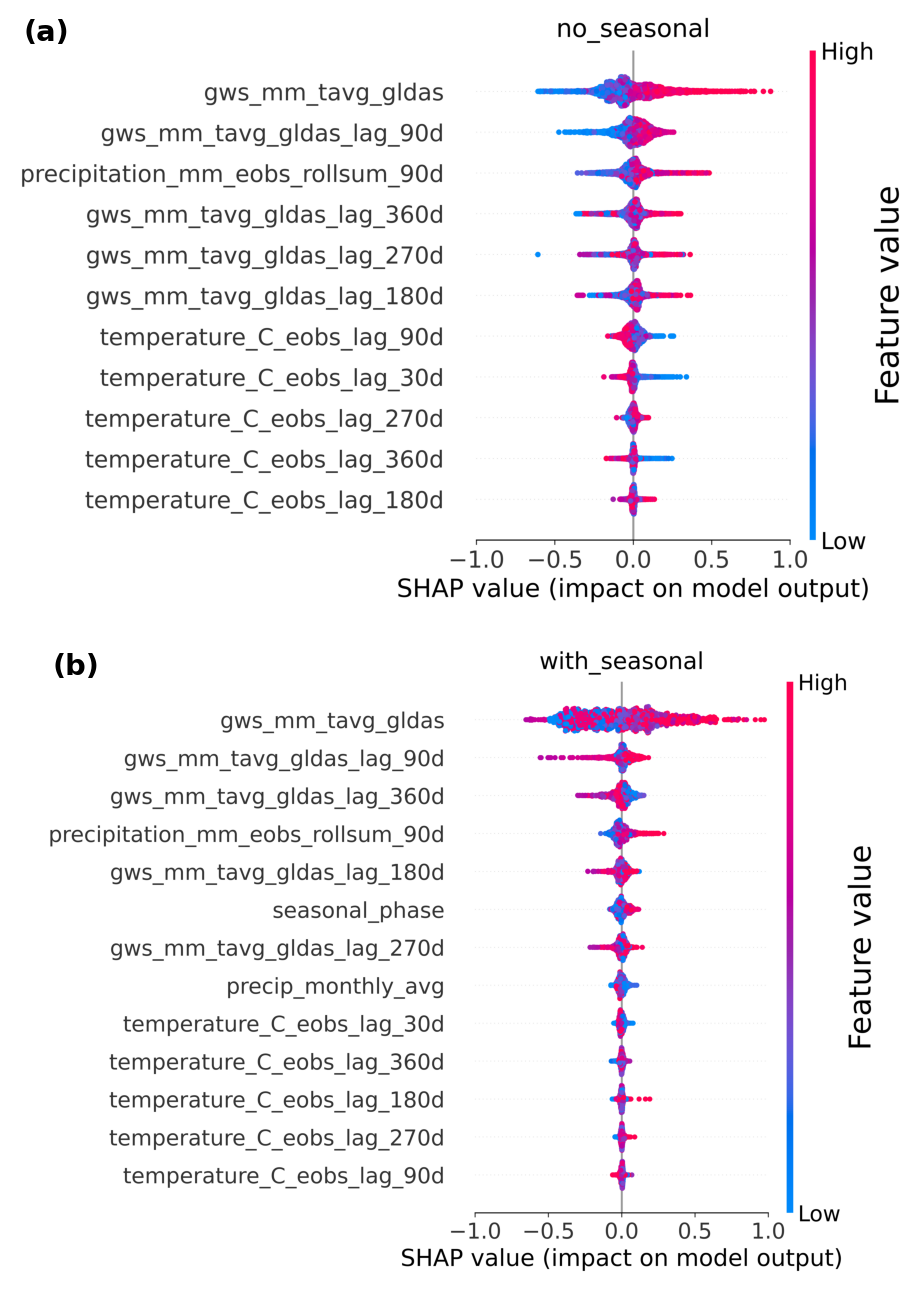

[SHAP] Saved stacked beeswarm JPEG to: shap_plots/beeswarm_stacked.jpg


In [8]:
SUBPLOT_LABEL_FS = 16

def _index_to_alpha_label(idx):
    letters = []
    while True:
        letters.append(chr(97 + idx % 26))
        idx = idx // 26 - 1
        if idx < 0:
            break
    return f"({''.join(reversed(letters))})"

def _concat_shap_for_feature_set(shap_values_all, feature_set_name, limit_wells=None):
    shap_arrays, feature_frames, used = [], [], 0
    for (_, fs), records in shap_values_all.items():
        if fs != feature_set_name:
            continue
        for rec in records:
            sv = rec['shap_values'].values if hasattr(rec['shap_values'], 'values') else rec['shap_values']
            shap_arrays.append(sv)
            feature_frames.append(rec['X_features'][rec['feature_names']])
            used += 1
            if limit_wells is not None and used >= limit_wells:
                break
        if limit_wells is not None and used >= limit_wells:
            break
    if not shap_arrays:
        return None, None, None
    features_df = pd.concat(feature_frames, ignore_index=True)
    return np.vstack(shap_arrays), features_df, list(features_df.columns)

def _apply_font_sizes_to_axes(fig, fonts):
    if not fonts:
        return
    tick_fs = fonts.get('tick')
    axis_label_fs = fonts.get('axis_label')
    cbar_tick_fs = fonts.get('cbar_tick', tick_fs)
    cbar_label_fs = fonts.get('cbar_label', axis_label_fs)
    for ax in fig.axes:
        if tick_fs is not None:
            ax.tick_params(axis='both', which='both', labelsize=tick_fs)
        if axis_label_fs is not None:
            ax.xaxis.label.set_size(axis_label_fs)
            ax.yaxis.label.set_size(axis_label_fs)
        if hasattr(ax, 'get_images') and len(ax.get_images()) == 0:
            if cbar_tick_fs is not None:
                ax.tick_params(axis='both', which='both', labelsize=cbar_tick_fs)
            if cbar_label_fs is not None:
                ax.yaxis.label.set_size(cbar_label_fs)

def _rc_updates_from_fonts(fonts=None, font_scale=1.0):
    fonts = fonts or {}
    scaled = lambda key: None if fonts.get(key) is None else float(fonts[key]) * float(font_scale)
    rc = {}
    mapping = {
        'base': ['font.size'],
        'title': ['axes.titlesize'],
        'axis_label': ['axes.labelsize'],
        'tick': ['xtick.labelsize', 'ytick.labelsize'],
        'legend': ['legend.fontsize'],
        'suptitle': ['figure.titlesize'],
    }
    for key, rc_keys in mapping.items():
        value = scaled(key)
        if value is not None:
            for rc_key in rc_keys:
                rc[rc_key] = value
    return rc

def _render_beeswarm_to_png_bytes(
    shap_mat, features_df, feature_names, title, max_display=20, rng=None,
    panel_dpi=600, fonts=None, font_scale=1.0, xlim=None
):
    rc_updates = _rc_updates_from_fonts(fonts, font_scale)
    with plt.rc_context(rc=rc_updates):
        try:
            shap.summary_plot(
                shap_mat, features=features_df, feature_names=feature_names,
                max_display=max_display, show=False, rng=rng
            )
        except TypeError:
            shap.summary_plot(
                shap_mat, features=features_df, feature_names=feature_names,
                max_display=max_display, show=False
            )

        fig = plt.gcf()
        if xlim is not None and fig.axes:
            try:
                main_ax = next(ax for ax in fig.axes if getattr(ax, 'collections', []))
            except StopIteration:
                main_ax = fig.axes[0]
            main_ax.set_xlim(xlim)

        if fig.axes:
            title_fs = fonts.get('title') * float(font_scale) if fonts and 'title' in fonts else None
            fig.axes[0].set_title(title, pad=10, fontsize=title_fs)

        _apply_font_sizes_to_axes(
            fig,
            {k: (v * float(font_scale) if v is not None else None) for k, v in (fonts or {}).items()},
        )

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=panel_dpi, bbox_inches='tight')
        plt.close(fig)

    buf.seek(0)
    return buf.getvalue()

def plot_stacked_beeswarms(
    shap_values_all, feature_sets, outdir='shap_plots', max_display=20, limit_wells=None,
    composite_fname='beeswarm_stacked.jpg', show=True, rng_seed=None, rng=None,
    final_dpi=600, panel_dpi=600, fonts=None, font_scale=1.0,
    subplot_label_fs=None, xlim=None
):
    os.makedirs(outdir, exist_ok=True)
    if rng is None and rng_seed is not None:
        rng = np.random.default_rng(rng_seed)

    child_rngs = None
    if rng is not None:
        state = rng.bit_generator.state
        try:
            base_seed = state['state']['state']
        except Exception:
            base_seed = abs(hash(repr(state))) % (2**32 - 1)
        child_rngs = [np.random.default_rng(s) for s in np.random.SeedSequence(base_seed).spawn(len(feature_sets))]

    png_images = []
    for i, fs_name in enumerate(feature_sets):
        shap_mat, features_df, feature_names = _concat_shap_for_feature_set(
            shap_values_all, fs_name, limit_wells=limit_wells
        )
        if shap_mat is None:
            print(f"[SHAP] No SHAP data for feature set '{fs_name}'. Skipping.")
            continue

        png_bytes = _render_beeswarm_to_png_bytes(
            shap_mat, features_df, feature_names, fs_name,
            max_display=max_display,
            rng=child_rngs[i] if child_rngs else rng,
            panel_dpi=panel_dpi,
            fonts=fonts,
            font_scale=font_scale,
            xlim=xlim,
        )
        png_images.append(plt.imread(io.BytesIO(png_bytes), format='png'))

    if not png_images:
        print('[SHAP] No SHAP data found.')
        return

    fig_height = sum(img.shape[0] for img in png_images) / float(panel_dpi)
    fig_width = max(img.shape[1] for img in png_images) / float(panel_dpi)
    fig, axes = plt.subplots(len(png_images), 1, figsize=(fig_width, fig_height), constrained_layout=True)
    axes = [axes] if len(png_images) == 1 else axes

    if subplot_label_fs is None:
        subplot_label_fs = (
            fonts['subplot_label'] * float(font_scale)
            if fonts and 'subplot_label' in fonts
            else SUBPLOT_LABEL_FS * float(font_scale)
        )

    for idx, (ax, img) in enumerate(zip(axes, png_images)):
        ax.imshow(img, zorder=0)
        ax.axis('off')
        ax.text(
            0.015, 0.985, _index_to_alpha_label(idx), transform=ax.transAxes,
            fontsize=subplot_label_fs, fontweight='bold', va='top', ha='left', zorder=5,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.15'),
        )

    outpath = os.path.join(outdir, composite_fname)
    fig.savefig(outpath, format='jpeg', dpi=final_dpi, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)
    print(f'[SHAP] Saved stacked beeswarm JPEG to: {outpath}')

compare_feature_sets = ['no_seasonal', 'with_seasonal']
available_fs = sorted({fs for _, fs in shap_values_all.keys()})
selected = [fs for fs in compare_feature_sets if fs in available_fs]
if len(selected) < 2:
    selected = available_fs[:2]

if len(selected) < 2:
    print('Need at least two feature sets with SHAP data.')
else:
    my_fonts = {
        'base': 11, 'title': 14, 'axis_label': 14, 'tick': 13,
        'legend': 11, 'cbar_tick': 13, 'cbar_label': 18,
        'suptitle': 16, 'subplot_label': 16,
    }
    plot_stacked_beeswarms(
        shap_values_all, feature_sets=selected, outdir='shap_plots', max_display=20,
        limit_wells=None, composite_fname='beeswarm_stacked.jpg', show=True,
        rng_seed=42, final_dpi=600, panel_dpi=600, fonts=my_fonts,
        font_scale=1.3, xlim=(-1, 1),
    )

### Final imputed table

In [9]:
df_imputed_vals = pd.concat(
    [frame for frames in imputed_all_models.values() for frame in frames],
    ignore_index=True,
)

print('Unique well_no values:', df_imputed_vals['well_no'].unique())
print('Unique feature_set values:', df_imputed_vals['feature_set'].unique())

selected_cols = df_imputed_vals[['well_no', 'date', 'gw_level_m_asl']].rename(
    columns={'gw_level_m_asl': 'gw_level_m_asl_imputed'}
)
df_merged = df_work.merge(selected_cols, on=['well_no', 'date'], how='left')

FINAL_PARQUET = '/content/imputed_gw_level.parquet'
df_merged.to_parquet(FINAL_PARQUET, index=False)
print(f'Saved final imputed table -> {FINAL_PARQUET}')
df_merged.head()

Unique well_no values: ['LT_35994' 'LV_22606' 'LT_220' 'LT_35995' 'LT_35996' 'LV_12225'
 'LV_22610']
Unique feature_set values: ['with_seasonal' 'no_seasonal']
Saved final imputed table -> /content/imputed_gw_level.parquet


,date,well_no,precipitation_mm_eobs,temperature_C_eobs,actual_evapotranspiration_mm_gleam,potential_evapotranspiration_mm_gleam,site,local_ID,altitude_ m_asl,gw_level_m_asl,...,gws_monthly_anomaly,gws_delta_30d,gws_recharge_event,below_zero_rolling_30d,permafrost_flag,temp_monthly_avg,precip_monthly_avg,gws_monthly_avg,gw_level_m_asl_original,gw_level_m_asl_imputed
0,2003-01-01,LT_220,0.8,-6.750000,0.032450,0.032450,NaN,NaN,NaN,NaN,...,NaN,NaN,False,NaN,False,-3.659976,1.285978,1863.082396,NaN,NaN
1,2003-01-02,LT_220,2.2,-13.090000,0.056737,0.056737,NaN,NaN,NaN,NaN,...,NaN,NaN,False,NaN,False,-3.659976,1.285978,1863.082396,NaN,NaN
2,2003-01-03,LT_220,0.9,-12.849999,0.046681,0.046681,NaN,NaN,NaN,NaN,...,NaN,NaN,False,NaN,False,-3.659976,1.285978,1863.082396,NaN,NaN
3,2003-01-04,LT_220,0.0,-17.260000,0.025061,0.025061,NaN,NaN,NaN,NaN,...,NaN,NaN,False,NaN,False,-3.659976,1.285978,1863.082396,NaN,NaN
4,2003-01-05,LT_220,0.0,-20.150000,0.005799,0.005799,NaN,NaN,NaN,NaN,...,NaN,NaN,False,NaN,False,-3.659976,1.285978,1863.082396,NaN,NaN


### Groundwater-level signal noise evaluation

In [10]:
df_sorted = df_imputed_vals.sort_values(['well_no', 'date']).copy()
df_sorted['gw_level_zscore'] = df_sorted.groupby('well_no')['gw_level_m_asl'].transform(
    lambda x: (x - x.mean()) / x.std()
)
noise_summary = df_sorted.groupby('well_no')['gw_level_zscore'].agg(std_dev='std', mean='mean').reset_index()
noise_summary['cv'] = noise_summary['std_dev'] / noise_summary['mean']
df_sorted['first_diff'] = df_sorted.groupby('well_no')['gw_level_zscore'].diff()
first_diff_std = df_sorted.groupby('well_no')['first_diff'].std().reset_index(name='std_first_diff')
noise_summary = noise_summary.merge(first_diff_std, on='well_no')
noise_summary

,well_no,std_dev,mean,cv,std_first_diff
0,LT_220,1.0,-1.089173e-15,-9.181281e+14,0.238963
1,LT_35994,1.0,7.218783e-16,1.385275e+15,0.084782
2,LT_35995,1.0,-1.441509e-14,-6.937177e+13,0.111109
3,LT_35996,1.0,-1.677297e-14,-5.961975e+13,0.157720
4,LV_12225,1.0,8.432106e-15,1.185943e+14,0.062012
5,LV_22606,1.0,4.162072e-15,2.402650e+14,0.163507
6,LV_22610,1.0,-2.161234e-15,-4.626986e+14,0.139810


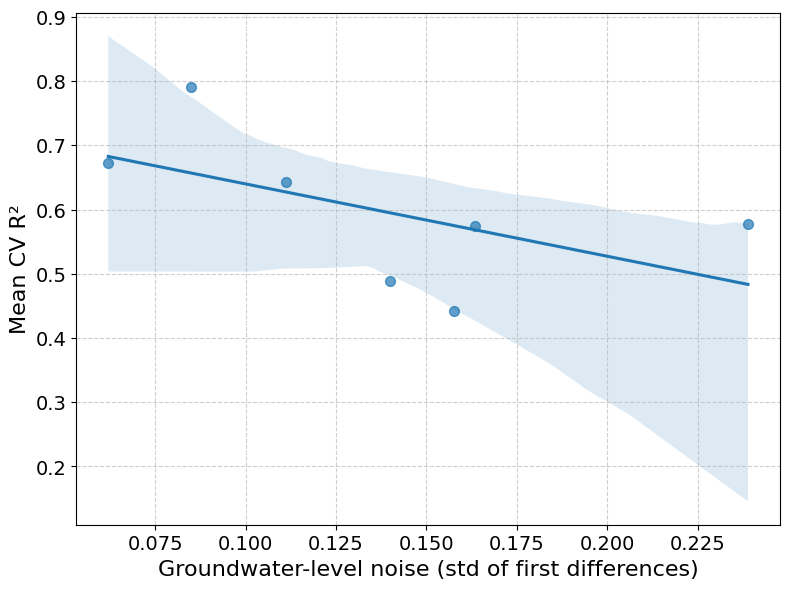

In [11]:
plot_df = summary[summary['well_no'] != 'AVERAGE'].copy().merge(noise_summary, on='well_no', how='left')

LABEL_FS, TICK_FS = 16, 14
plt.figure(figsize=(8, 6))
ax = sns.regplot(
    data=plot_df, x='std_first_diff', y='CV_R2 mean',
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'linewidth': 2.2},
)
ax.set_xlabel('Groundwater-level noise (std of first differences)', fontsize=LABEL_FS)
ax.set_ylabel('Mean CV R²', fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.grid(True, which='major', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('gw_level_noise.jpeg', dpi=600, bbox_inches='tight', pad_inches=0.2)
plt.show()

### VIF table

In [12]:
def compute_avg_vif_table(vif_all):
    data = {}
    for feature_set_name, vif_dicts in vif_all.items():
        if not vif_dicts:
            continue
        vif_df = pd.DataFrame(vif_dicts)
        data[(feature_set_name, 'mean')] = vif_df.mean().round(1)
        data[(feature_set_name, 'std')] = vif_df.std().round(1)
    return pd.DataFrame(data).sort_index(axis=1, level=0)

avg_vif_df = compute_avg_vif_table(vif_all)
avg_vif_df.to_csv('avg_vif_imput.csv')
avg_vif_df

no_seasonal      with_seasonal     
                                         mean  std          mean  std
gws_mm_tavg_gldas                         4.3  0.8           4.6  1.7
gws_mm_tavg_gldas_lag_180d                4.9  0.3           4.3  1.3
gws_mm_tavg_gldas_lag_270d                4.4  0.3           4.2  1.2
gws_mm_tavg_gldas_lag_360d                4.1  0.3           3.6  0.6
gws_mm_tavg_gldas_lag_90d                 4.7  0.4           4.6  1.6
precip_monthly_avg                        NaN  NaN           3.9  0.2
precipitation_mm_eobs_rollsum_90d         1.9  0.5           2.1  0.7
seasonal_phase                            NaN  NaN           3.2  0.1
temperature_C_eobs_lag_180d               3.9  0.1           3.8  0.4
temperature_C_eobs_lag_270d               3.9  0.1           4.1  0.3
temperature_C_eobs_lag_30d                4.0  0.3           4.1  0.4
temperature_C_eobs_lag_360d               3.9  0.2           3.9  0.4
temperature_C_eobs_lag_90d                3.8  0.1           4.0  0.3

### Feature importance

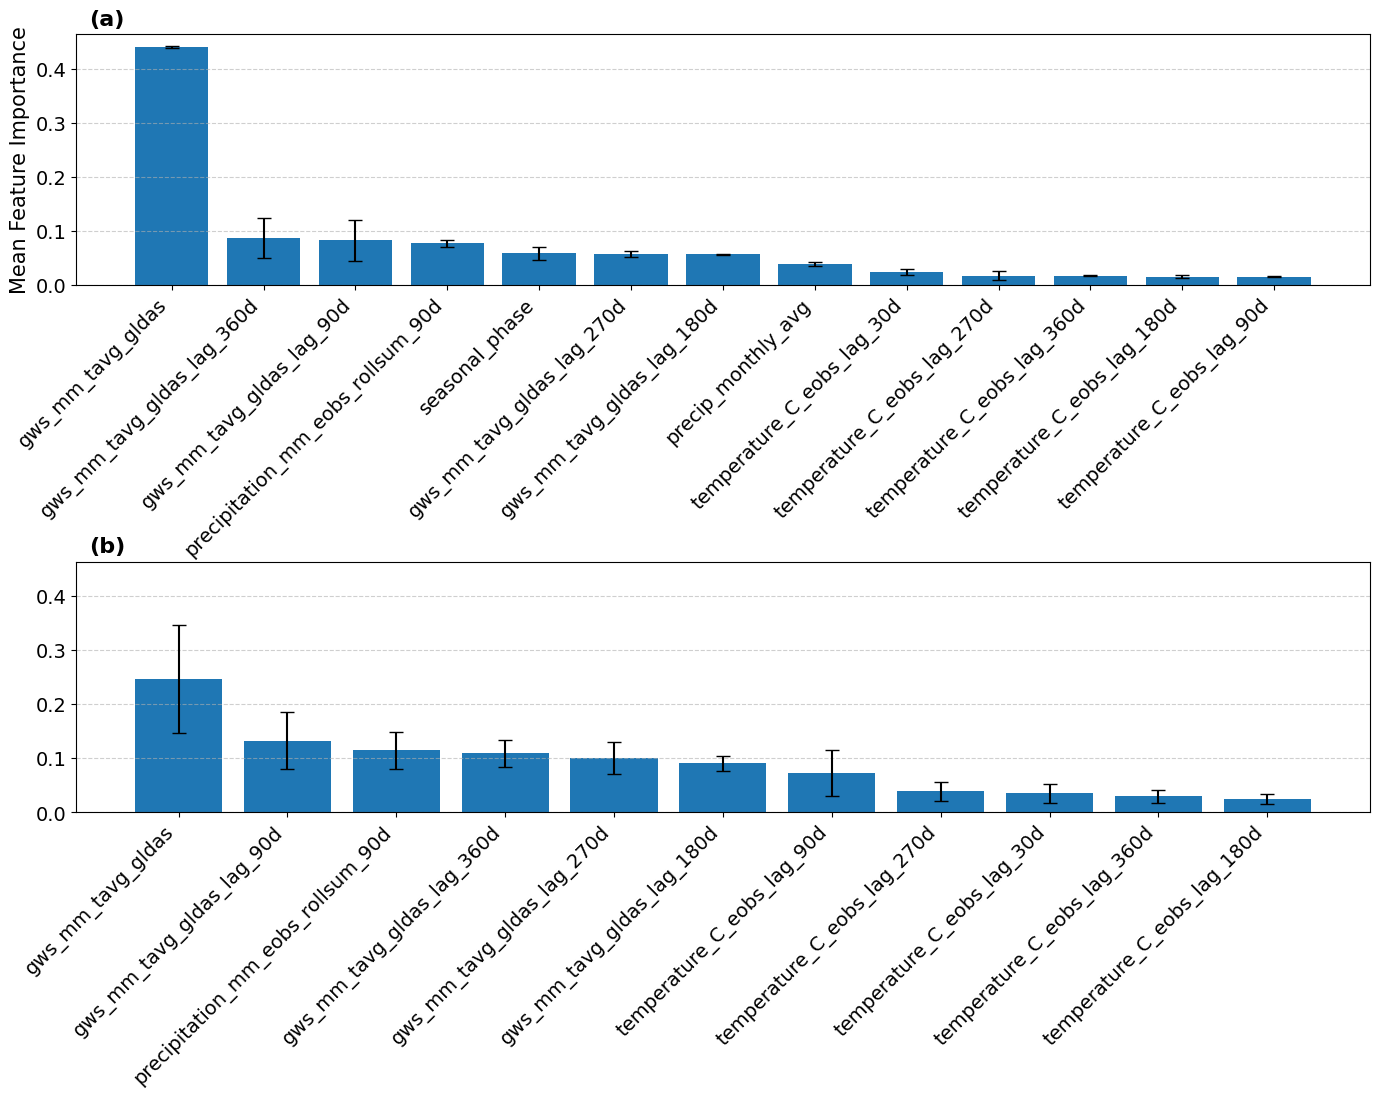

In [13]:
plot_keys = list(feature_importances_all.keys())[:2]

if len(plot_keys) < 2:
    print('Need at least two models to plot one-above-the-other.')
else:
    LABEL_FS, TICK_FS, SUBPLOT_LABEL_FS = 15, 14, 16
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)
    axes = [axes] if not isinstance(axes, (list, np.ndarray)) else axes

    for idx, key in enumerate(plot_keys):
        df_feat = pd.DataFrame(feature_importances_all[key]).fillna(0)
        mean_importance = df_feat.mean().sort_values(ascending=False)
        std_importance = df_feat.std().reindex(mean_importance.index)
        ax = axes[idx]
        positions = range(len(mean_importance))

        ax.bar(positions, mean_importance.values, yerr=std_importance.values, capsize=5)
        ax.set_xticks(positions)
        ax.set_xticklabels(mean_importance.index, rotation=45, ha='right', fontsize=TICK_FS)
        ax.tick_params(axis='y', labelsize=TICK_FS)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        if idx == 0:
            ax.set_ylabel('Mean Feature Importance', fontsize=LABEL_FS)
        ax.text(
            0.01, 1.02, f'({chr(97 + idx)})', transform=ax.transAxes,
            fontsize=SUBPLOT_LABEL_FS, fontweight='bold', va='bottom', ha='left', clip_on=False,
        )

    plt.tight_layout()
    plt.subplots_adjust(hspace=1.10, bottom=0.18)
    plt.savefig('feature_importance_comparison_imput.jpeg', dpi=600, bbox_inches='tight')
    plt.show()

### Groundwater-level time series

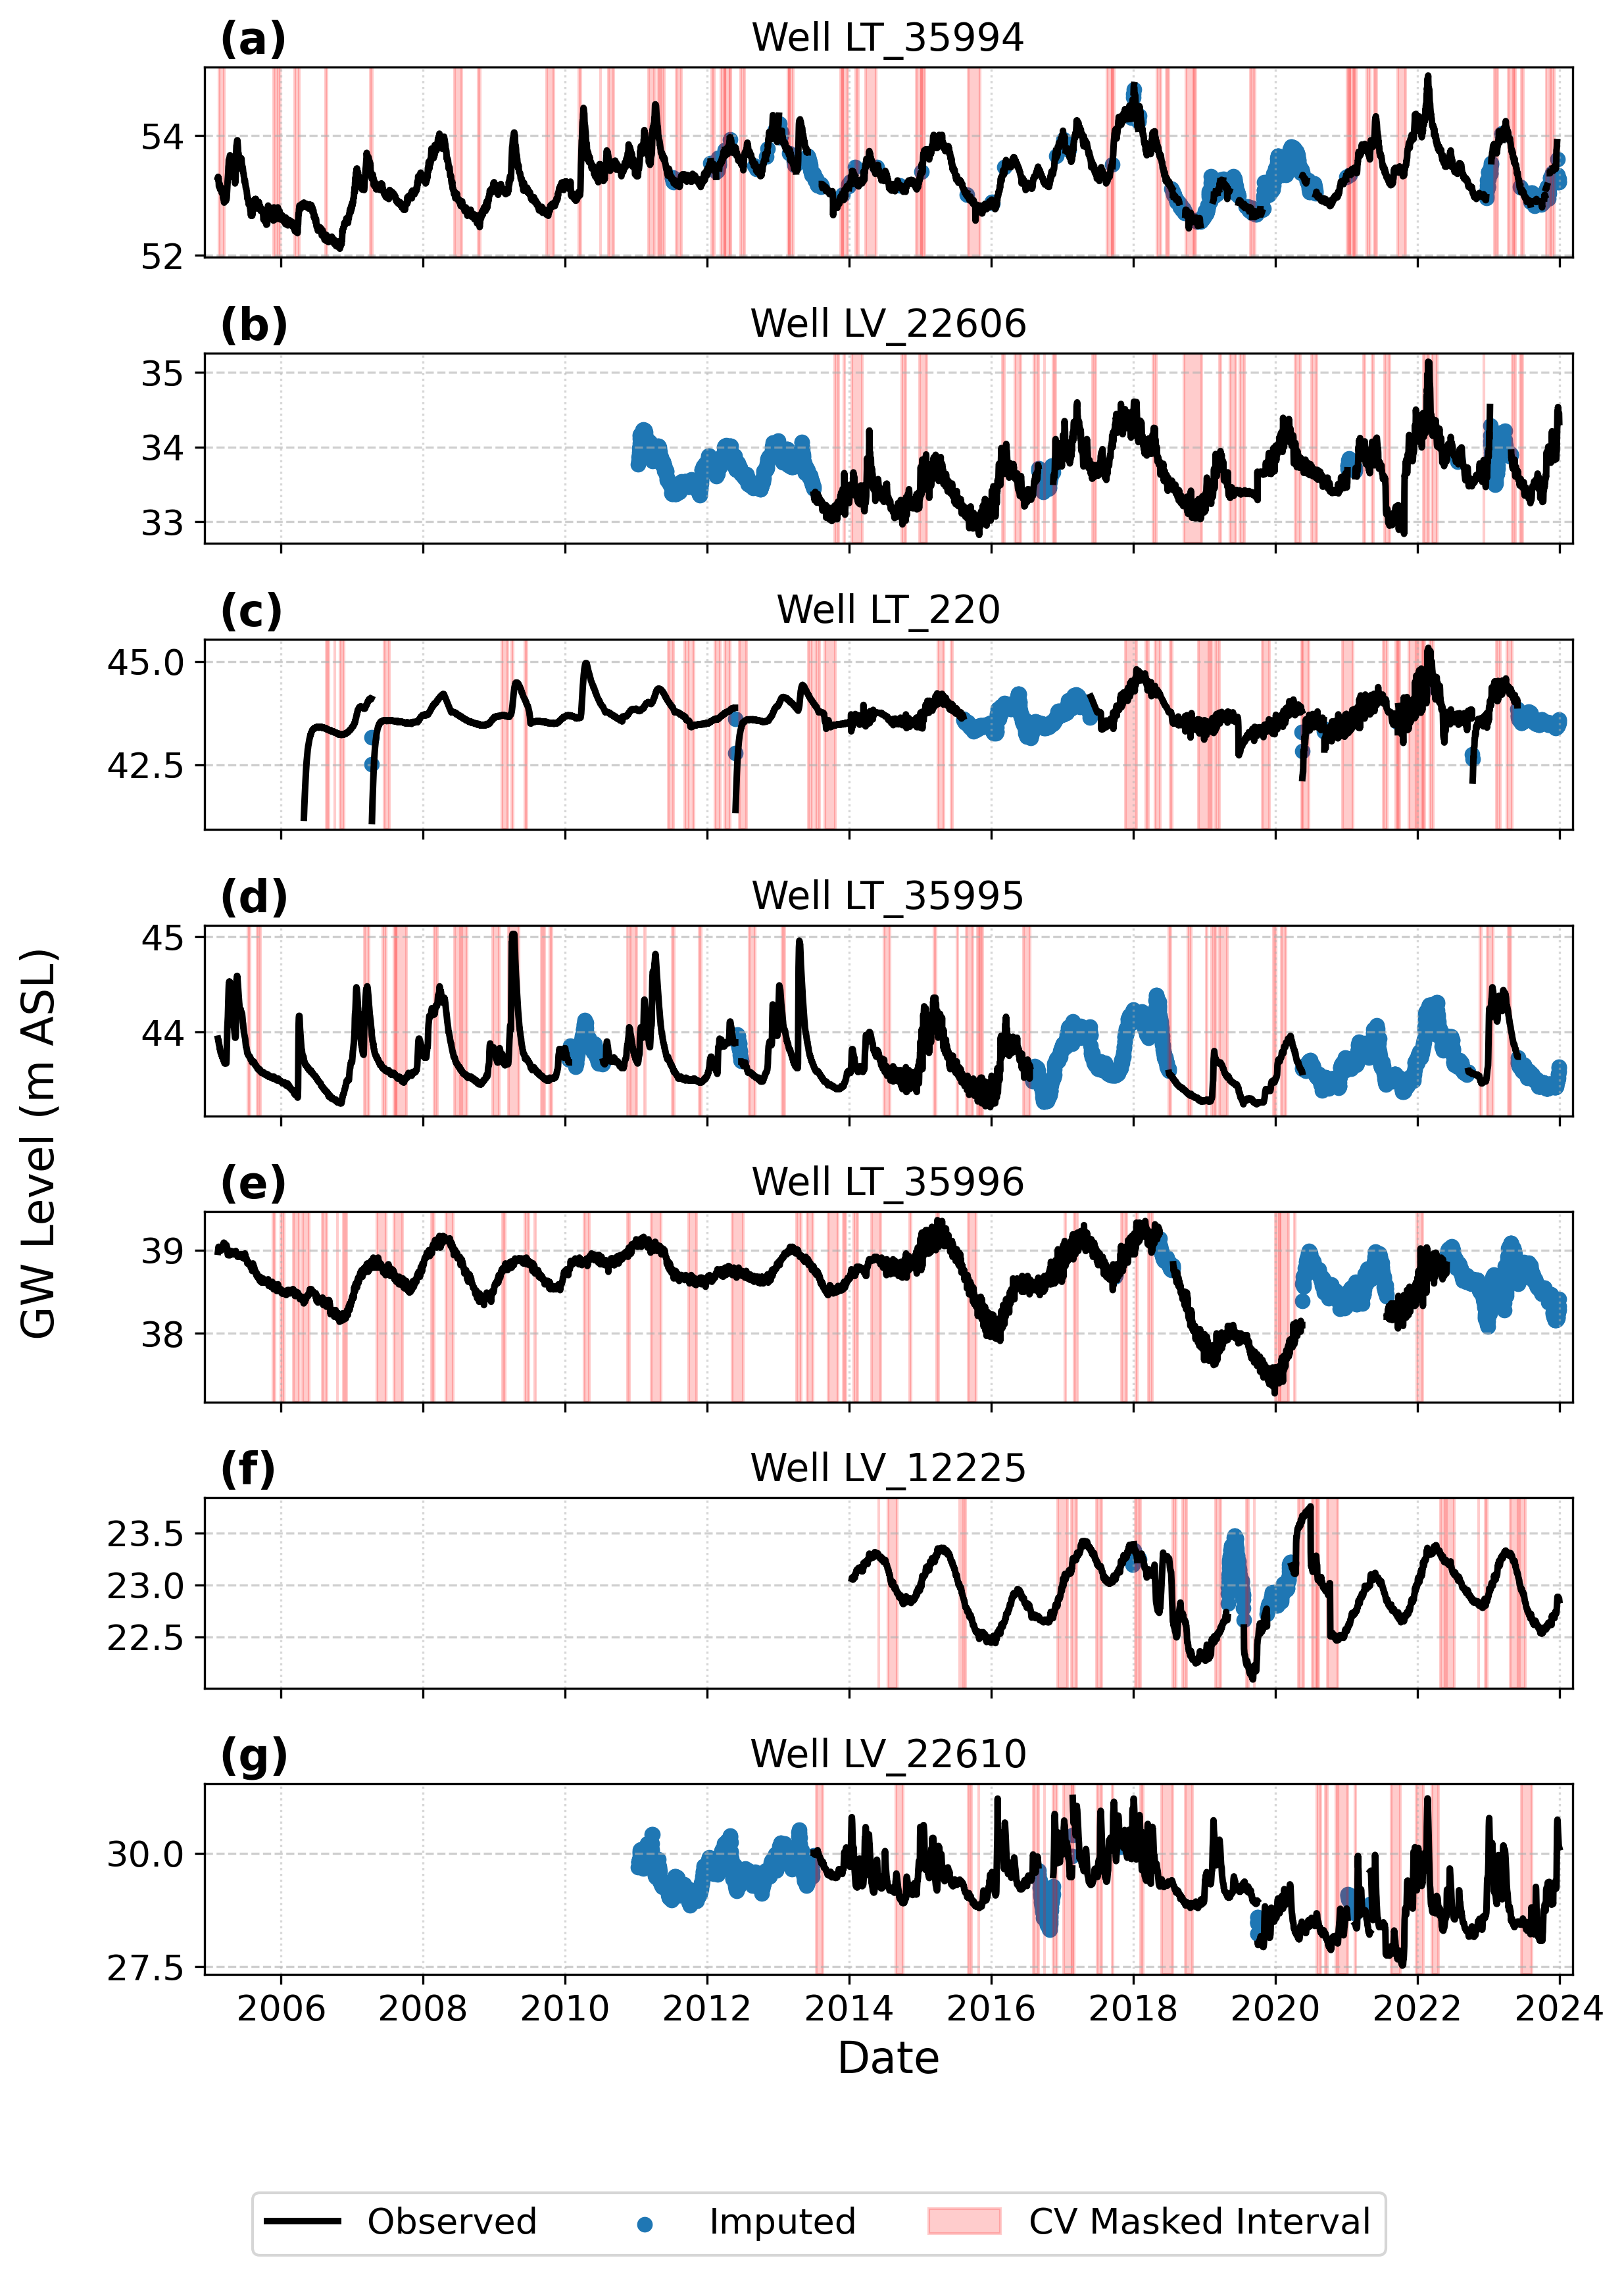

In [14]:
A4_W_IN, A4_H_IN, DPI = 8.27, 11.69, 300
plt.rcParams.update({
    'figure.dpi': DPI,
    'savefig.dpi': DPI,
    'axes.titlesize': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

plots = []
for (model_name, feature_set_name), data_list in imputed_all_models.items():
    if not data_list:
        continue

    df_imputed = pd.concat(data_list).sort_values(['well_no', 'date'])
    for well_no in df_imputed['well_no'].unique():
        imputed = df_imputed[df_imputed['well_no'] == well_no].sort_values('date')
        actual = df_work[df_work['well_no'] == well_no].copy()
        actual['date'] = pd.to_datetime(actual['date'])
        actual['was_originally_missing'] = actual[target_col].isnull()

        merged = pd.merge(imputed, actual[['date', 'was_originally_missing']], on='date', how='left')
        observed = merged[~merged['was_originally_missing']][['date', target_col]].copy().sort_values('date')
        imputed_only = merged[merged['was_originally_missing']].copy()
        observed['gap'] = observed['date'].diff().dt.days.fillna(1)
        observed['segment'] = (observed['gap'] > 1).cumsum()

        masked_segments = cv_masked_intervals.get((well_no, model_name, feature_set_name), [])
        plots.append((well_no, model_name, feature_set_name, observed, imputed_only, masked_segments))

if not plots:
    raise ValueError('No plots to draw.')

fig, axes = plt.subplots(len(plots), 1, figsize=(A4_W_IN, A4_H_IN), sharex=True)
axes = [axes] if len(plots) == 1 else axes
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
legend_pairs = []

for idx, (ax, plot_data) in enumerate(zip(axes, plots)):
    well_no, model_name, feature_set_name, observed, imputed_only, masked_segments = plot_data

    for i, seg in observed.groupby('segment'):
        h_obs = ax.plot(seg['date'], seg[target_col], color='black', linewidth=2.4, label='Observed' if i == 0 else '')
        if i == 0:
            legend_pairs.append((h_obs[0], 'Observed'))

    if not imputed_only.empty:
        h_imp = ax.scatter(imputed_only['date'], imputed_only[target_col], s=22, color='tab:blue', label='Imputed')
        legend_pairs.append((h_imp, 'Imputed'))

    for j, (start_date, end_date) in enumerate(masked_segments):
        h_span = ax.axvspan(start_date, end_date, color='red', alpha=0.2, label='CV Masked Interval' if j == 0 else '')
        if j == 0:
            legend_pairs.append((h_span, 'CV Masked Interval'))

    ax.text(
        0.01, 1.02, f'({chr(97 + idx)})', transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False,
    )
    ax.set_title(f'Well {well_no}', pad=6)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.margins(x=0.01)

    if idx < len(plots) - 1:
        ax.tick_params(axis='x', which='both', labelbottom=False)

axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)
axes[-1].set_xlabel('Date')
fig.supylabel('GW Level (m ASL)', x=0.01, fontsize=16)

unique = OrderedDict()
for handle, label in legend_pairs:
    if label and label not in unique:
        unique[label] = handle

fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.legend(
    list(unique.values()), list(unique.keys()),
    loc='lower center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.01),
)
fig.savefig('stacked_imputation_timeseries.jpeg', bbox_inches='tight', pad_inches=0.3)
plt.show()